### Homework 3 

Student = David Medina Rosner

Id = F11115117

In [1]:
# libraries
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

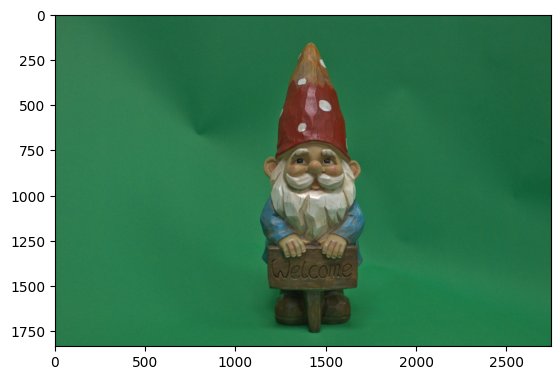

In [2]:
# read image
img = cv.imread('Santa.jpg') # opencv works with BGR
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB) # matplotlib works with RGB

plt.imshow(img_rgb)
plt.show()

In [3]:
# choose points for projection of 3d to 2d
points_2d = np.array([[1418, 168],
                      [1526, 402],
                      [1685, 851],
                      [1693, 1360],
                      [1661, 1502],
                      [1598, 1700],
                      [1454, 1744],
                      [1411, 1751],
                      [1236, 1693],
                      [1194, 1497],
                      [1160, 1346],
                      [1170, 828],
                      [1301, 405],
                      [1443, 814],
                      [1349, 750],
                      [1512, 752]])

points_3d = np.array([[0.466969, -13.003787, 68.222092],
                      [-4.734668, -4.645988, 56.826958],
                      [-11.679994, -0.597262, 37.356667],  
                      [-12.574524, 2.752151, 13.632814],  
                      [-9.783403, 15.474633, 11.475644],
                      [-7.089449, 10.456135, 0.820255],   
                      [-1.325279, 15.071527, 0.008385],
                      [0.930342, 15.814737, 0.540715],
                      [9.131970, 7.916779, 0.051152], 
                      [10.416494, 15.274540, 11.582716],
                      [12.635828, 2.631317, 14.301454],
                      [11.831197, -0.336740, 38.751217],
                      [5.889037, -3.890480, 54.901043],
                      [-0.265115, 9.665230, 40.716331],
                      [3.678199, 6.815482, 43.061607], 
                      [-3.374154, 6.983824, 42.845634]])

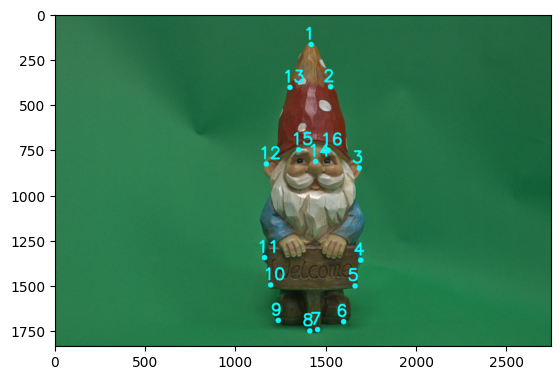

True

In [4]:
img2save = img_rgb.copy()

# draw circles of the selected points for reference
for i, point in enumerate(points_2d, start=1):
    x, y = point
    cv.circle(img2save, (x, y), 15, (0, 255, 255), -1) # points
    cv.putText(img2save, str(i), (x - 40, y - 30), cv.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 255), 10) # labels

# show image with reference points
plt.imshow(img2save)
plt.show()


# save image with reference points and labels
img2save = cv.cvtColor(img2save, cv.COLOR_RGB2BGR)
cv.imwrite('reference_points.png', img2save)

In [5]:
# load points of .xyz file
xyz_list = np.loadtxt('Santa.xyz') # about 381.613 points

# list of xyz coordinates for all 381.613 points
xyz_without_normal = xyz_list[ : , 0:3]
print('xyz coordinates for the whole file:\n', xyz_without_normal)

xyz coordinates for the whole file:
 [[ 9.455082e+00  7.318630e+00  9.354700e-02]
 [ 9.444080e+00  7.322497e+00  7.973800e-02]
 [ 9.440523e+00  7.362862e+00  9.662000e-02]
 ...
 [-8.988998e+00  4.742631e+00  8.385000e-03]
 [-9.000723e+00  4.783324e+00  8.385000e-03]
 [-9.140589e+00  5.305424e+00  8.385000e-03]]


In [6]:
# list of y normal for all points, this is important, to select what rgb colors to save
normal_y = xyz_list[ : , 4]
print('normal of y:\n', normal_y)

normal of y:
 [ 0.296732  0.298594  0.301801 ... -0.140756 -0.144882 -0.133984]


In [7]:
# function to calculate the Projection Matrix of 3d points to 2d points by using DLT 
def calculate_matrix_P(points_3d, points_2d):
    p = []

    # DLT (Direct Linear Transformation)
    for point_3d, point_2d in zip(points_3d, points_2d):
        x, y, z = point_3d
        u, v = point_2d

        p.append([x, y, z, 1, 0, 0, 0, 0, -u*x, -u*y, -u*z, -u])
        p.append([0, 0, 0, 0, x, y, z, 1, -v*x, -v*y, -v*z, -v])
        
    p = np.array(p)
    
    # SVD (Singular Value Decomposition)
    u, s, v = np.linalg.svd(p)
    v = np.transpose(v)
    
    p = [v[0:4, 11], v[4:8, 11], v[8:12, 11]]
    p = p / p[2][3] # normalize
    
    return p

In [8]:
# find the Projection Matrix
p_matrix = calculate_matrix_P(points_3d, points_2d)
print('Projection Matrix:\n', p_matrix)

Projection Matrix:
 [[-2.18430618e+01 -9.11663655e+00 -2.47874760e+00  1.43151069e+03]
 [-1.35130929e+00 -2.43539205e+00 -2.20069261e+01  1.61638975e+03]
 [-1.02200333e-03 -6.53648336e-03 -1.72721241e-03  1.00000000e+00]]


In [9]:
# create a column vector of ones with the same number of rows as points_3d
ones_column = np.ones((xyz_without_normal.shape[0], 1), dtype=xyz_without_normal.dtype)

# to point_3d, add a column of ones
xyz_with_ones = np.concatenate((xyz_without_normal, ones_column), axis=1)
print('X_3d:\n', xyz_with_ones)

X_3d:
 [[ 9.455082e+00  7.318630e+00  9.354700e-02  1.000000e+00]
 [ 9.444080e+00  7.322497e+00  7.973800e-02  1.000000e+00]
 [ 9.440523e+00  7.362862e+00  9.662000e-02  1.000000e+00]
 ...
 [-8.988998e+00  4.742631e+00  8.385000e-03  1.000000e+00]
 [-9.000723e+00  4.783324e+00  8.385000e-03  1.000000e+00]
 [-9.140589e+00  5.305424e+00  8.385000e-03  1.000000e+00]]


In [10]:
# function to project 3d points to an estimated 2d one. This estimation is done by performing matrix 
# multiplication between the Projection Matrix and every xyz coordinate for all points
def reproject_3d_to_2d(xyz_file_list, p_matrix):
    projection_2d = []

    # iterate though all 381.613 points
    for xyz in xyz_file_list:
        point_2d = p_matrix @ xyz.T # matrix multiplication
        point_2d = point_2d / point_2d[2] # normalize
        
        projection_2d.append(point_2d)
    return np.array(projection_2d)

In [11]:
# find the estimated 2d points
projection_2d = reproject_3d_to_2d(xyz_with_ones, p_matrix)
print('projected 2d points:\n', projection_2d)

projected 2d points:
 [[1.22889088e+03 1.68064107e+03 1.00000000e+00]
 [1.22913201e+03 1.68095183e+03 1.00000000e+00]
 [1.22915698e+03 1.68097454e+03 1.00000000e+00]
 ...
 [1.61996052e+03 1.65288076e+03 1.00000000e+00]
 [1.62026382e+03 1.65322495e+03 1.00000000e+00]
 [1.62395046e+03 1.65766052e+03 1.00000000e+00]]


In [12]:
# function to extract the RGB color, given the estimation of 2d points
def get_color_from_img(img, projection_points):
    color = []

    # iterate through all 381.613 points
    for point in projection_points:
        x, y = point[0], point[1]

        # convert to integer, drop off decimal
        x, y = int(x), int(y)
        
        color.append(img[y][x])
    return np.array(color)

In [13]:
# get list containing the RGB color for each point
rgb_color_list = get_color_from_img(img_rgb, projection_2d)
print('list of RGB colors for the file:\n', rgb_color_list)

list of RGB colors for the file:
 [[27 34 16]
 [28 37 16]
 [28 37 16]
 ...
 [59 55 28]
 [58 57 27]
 [49 54 24]]


In [14]:
# open file of xyz coordinates BUT as a string list
with open('Santa.xyz', mode='r') as f:
    text = f.read() # read whole file as single string

text_list = text.split('\n')

del text_list[381613] # delete empty element

In [15]:
# append RGB colors to each point string, and save to .txt
with open('F11115117.txt','w') as fp:
    for idx, line in enumerate(text_list):
        if normal_y[idx] >= 0: # to ignore painting the back
            r, g, b = rgb_color_list[idx]
            fp.writelines(line + f'{str(r)} {str(g)} {str(b)} 255\n')